# Classical LBM Baselines

This notebook runs the first two reference simulations for the quantum CFD project: D1Q3 diffusion/advection-diffusion and D2Q9 Taylor-Green vortex.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import matplotlib.pyplot as plt
import numpy as np

from pq_cfd import SimulationConfig, run_d1q3, run_d2q9

In [2]:
d1_config = SimulationConfig(
    grid_shape=(128,),
    steps=100,
    tau=0.8,
    initial_condition="sinusoidal",
    sample_interval=20,
    amplitude=0.03,
)
d1 = run_d1q3(d1_config)

print("D1Q3 metrics")
for key, value in d1.metrics.items():
    print(f"{key}: {value:.6e}")

D1Q3 metrics
mass_initial: 1.280000e+02
mass_final: 1.280000e+02
mass_drift: -8.810730e-13
mass_drift_absolute: 8.810730e-13
mass_drift_relative: 6.883383e-15
diffusivity: 1.000000e-01
relative_l2_error_density: 2.724717e-06
runtime_seconds: 5.088000e-03


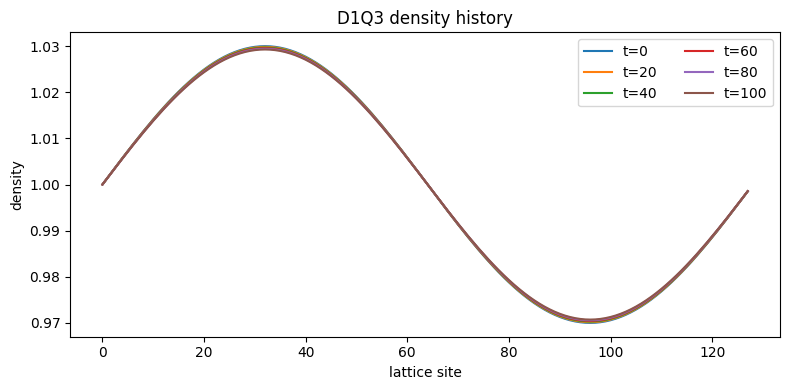

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(d1.density.size)
for step, density in zip(d1.history.steps, d1.history.density):
    ax.plot(x, density, label=f"t={step}")
ax.set_title("D1Q3 density history")
ax.set_xlabel("lattice site")
ax.set_ylabel("density")
ax.legend(ncol=2)
fig.tight_layout()

In [4]:
d2_config = SimulationConfig(
    grid_shape=(64, 64),
    steps=100,
    tau=0.8,
    initial_condition="taylor_green",
    sample_interval=25,
    amplitude=0.03,
)
d2 = run_d2q9(d2_config)

print("D2Q9 metrics")
for key, value in d2.metrics.items():
    print(f"{key}: {value:.6e}")

D2Q9 metrics
mass_initial: 4.096000e+03
mass_final: 4.096000e+03
mass_drift: -2.819434e-11
mass_drift_absolute: 2.819434e-11
mass_drift_relative: 6.883383e-15
viscosity: 1.000000e-01
relative_l2_error_velocity: 2.890700e-02
runtime_seconds: 5.829490e-02


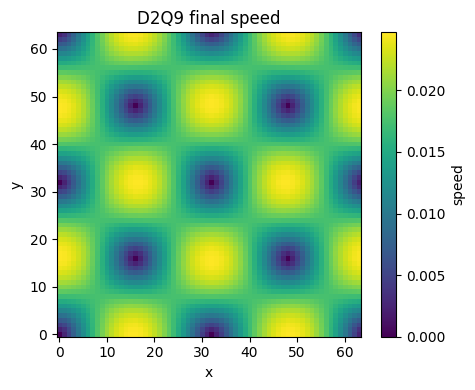

In [5]:
speed = np.sqrt(d2.velocity[0] ** 2 + d2.velocity[1] ** 2)

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(speed.T, origin="lower", cmap="viridis")
ax.set_title("D2Q9 final speed")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(image, ax=ax, label="speed")
fig.tight_layout()

## Analysis

This baseline notebook is the smoke test for the research path. D1Q3 should be treated as the clean mathematical target for the next quantum operator model because its behavior is simple, conservative, and easy to compare step by step. D2Q9 is already more fluid-like, but this notebook only verifies that the solver runs and produces plausible low-Mach Taylor-Green dynamics; the dedicated validation and order-study notebooks carry the serious numerical conclusions.

My reading of the current outputs is that the project is ready for quantum emulation on D1Q3, but not yet ready to claim a high-order D2Q9 CFD result. The D2Q9 baseline is stable and useful, but the later notebooks show that velocity convergence needs more diagnosis before we introduce a more complex LBE variant.
